## Build A Basic Chatbot With Langgraph(GRAPH API)

### State: the graph's shared memory

`State` defines the data that moves between every node in the graph. The `messages` field is annotated with `add_messages`, which is a LangGraph reducer: instead of replacing the old conversation each time a node returns new messages, LangGraph appends the new messages to the existing history. This is what lets each later step see the full conversation so far.


In [1]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x72d4bfe4b380>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72d4bfe4be00>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x72d4bfefb9d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72d4bfc58410>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### The chatbot node

A LangGraph node is just a Python function that receives the current `state` and returns a partial state update. Here the node sends the current message history to the LLM, then returns the model response under the same `messages` key so `add_messages` can append it to the conversation.


In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

### Building the first graph

This first graph has a single real node: `llmchatbot`. `START` tells LangGraph where execution begins, and `END` tells it where to stop. After `compile()`, the graph becomes runnable with `.invoke()` for a full response or `.stream()` for step-by-step events.


In [6]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
graph = graph_builder.compile()

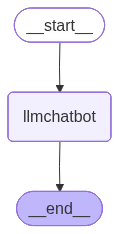

In [7]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
response = graph.invoke({"messages":"hi"})
response

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='5ee1b4d6-b766-401f-abd9-fdd44e29abcc'),
  AIMessage(content='<think>\nOkay, the user said "hi". That\'s pretty straightforward. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer help. Maybe something like, "Hello! How can I assist you today?" That should cover it. I don\'t see any hidden context here, so keeping it simple and polite is best.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 9, 'total_tokens': 97, 'completion_time': 0.156049318, 'completion_tokens_details': None, 'prompt_time': 0.000388822, 'prompt_tokens_details': None, 'queue_time': 0.158533156, 'total_time': 0.15643814}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provid

In [9]:
response["messages"][-1].content

'<think>\nOkay, the user said "hi". That\'s pretty straightforward. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer help. Maybe something like, "Hello! How can I assist you today?" That should cover it. I don\'t see any hidden context here, so keeping it simple and polite is best.\n</think>\n\nHello! How can I assist you today? 😊'

In [10]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user said "Hi How are you?" which is a casual greeting. I need to respond in a friendly and welcoming manner. First, I should acknowledge their greeting and offer a cheerful response. I'll let them know I'm doing well and ask how they're doing to keep the conversation flowing. Keeping it simple and open-ended will encourage them to share more if they want to. I should maintain a warm and approachable tone throughout.
</think>

Hello! I'm doing well, thank you for asking. How are you today? I hope you're having a great day! 😊


### Adding external tools

Tools give the model actions it cannot perform by text generation alone. `TavilySearch` lets the agent fetch web search results, while the custom `multiply` function shows how normal Python functions can become tools when they have clear type hints and a useful docstring.


In [11]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph - Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your appl

In [12]:
## custom function tool 
def multiply(a :int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

### Binding tools to the model

`bind_tools()` does not run the tools immediately. It gives the LLM the tool schemas, so the model can decide whether the next assistant message should answer directly or request one or more tool calls with structured arguments.


In [13]:
tools = [tavily_tool, multiply]
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x72d4bfefb9d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72d4bfc58410>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

### Tool-calling graph: one tool round

This graph adds two important pieces. `ToolNode(tools)` executes any tool calls requested by the assistant message, and `tools_condition` inspects the latest assistant message to choose the next edge. If there is a tool call, execution goes to `tools`; if not, execution ends.

In this version, the graph stops after the tool node. That means you can inspect tool results, but the model does not get a second turn to summarize those results into a final natural-language answer.


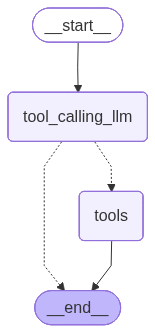

In [14]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
response = graph.invoke({"messages": "what is the latest ai news"})
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.securityweek.com/ai-fuels-industrial-cybercrime-as-time-to-exploit-shrinks-to-hours/", "title": "AI Fuels ‘Industrial’ Cybercrime as Time-to-Exploit Shrinks to Hours - SecurityWeek", "score": 0.74316806, "published_date": "Thu, 30 Apr 2026 18:54:15 GMT", "content": "## Latest News\\n\\n Anthropic Unveils Claude Security to Counter AI-Powered Exploit Surge\\n SonicWall Urges Immediate Patching of Firewall Vulnerabilities\\n SAP NPM Packages Targeted in Supply Chain Attack\\n Critical Gemini CLI Flaw Enabled Host Code Execution, Supply Chain Attacks\\n EnOcean SmartServer Flaws Expose Buildings to Remote Hacking\\n Critical cPanel & WHM Vulnerability Exploited as Zero-Day for Months\\n ‘Copy Fail’ Logic Flaw in Linux Kernel Enables System Takeover\\n Sandhills Medical Says Ransomware Breach Affects 170,000\\n\\n#### Trending\\n\\n## Daily Briefing Newsletter\\n\\nSubsc

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9pcf5xw9g)
 Call ID: 9pcf5xw9g
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.securityweek.com/ai-fuels-industrial-cybercrime-as-time-to-exploit-shrinks-to-hours/", "title": "AI Fuels ‘Industrial’ Cybercrime as Time-to-Exploit Shrinks to Hours - SecurityWeek", "score": 0.74316806, "published_date": "Thu, 30 Apr 2026 18:54:15 GMT", "content": "## Latest News\n\n Anthropic Unveils Claude Security to Counter AI-Powered Exploit Surge\n SonicWall Urges Immediate Patching of Firewall Vulnerabilities\n SAP NPM 

In [17]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (k2at9vxzg)
 Call ID: k2at9vxzg
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [18]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (zm2p9wdnn)
 Call ID: zm2p9wdnn
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (mjep0mm8g)
 Call ID: mjep0mm8g
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/ai-arms-race-accelerates-with-new-models-from-openai-deepseek-and-anthropic/", "title": "AI Arms Race Accelerates With New Models from OpenAI, DeepSeek and Anthropic - CNET", "score": 0.6530611, "published_date": "Fri, 24 Apr 2026 19:48:00 GMT", "content": "# AI Arms Race Accelerates With New Models from OpenAI, DeepSeek an

## ReAct Agent Architecture

ReAct means the agent alternates between reasoning with the LLM and acting with tools. The key difference from the previous graph is the edge from `tools` back to `tool_calling_llm`. After tools run, their results are appended to `messages`, then the LLM sees those tool results and can either call another tool or produce the final answer.


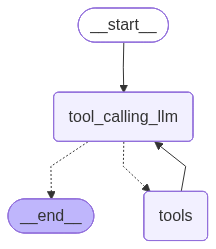

In [19]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9d1s4sv23)
 Call ID: 9d1s4sv23
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (cy26qr6g8)
 Call ID: cy26qr6g8
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnet.com/tech/services-and-software/ai-arms-race-accelerates-with-new-models-from-openai-deepseek-and-anthropic/", "title": "AI Arms Race Accelerates With New Models from OpenAI, DeepSeek and Anthropic - CNET", "score": 0.6530611, "published_date": "Fri, 24 Apr 2026 19:48:00 GMT", "content": "# AI Arms Race Accelerates With New Models from OpenAI, DeepSeek an

## Adding Memory In Agentic Graph

`MemorySaver` adds short-term memory to the graph by saving checkpoints after each run. When we compile the graph with `checkpointer=memory`, LangGraph can reload the previous state instead of treating every call as a brand-new conversation.

The `thread_id` inside `config` is the key that tells LangGraph which conversation history to continue. If two calls use the same `thread_id`, the second call can see messages from the first call. Without that config, the model only sees the messages passed into the current `graph.invoke`, so it cannot answer follow-up questions like "what is my name?" from an earlier turn.


In [21]:
response = graph.invoke(
    {"messages": "Hello, my name is Khaled"}
)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Khaled
================================== Ai Message ==================================

Hello Khaled! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know!


In [22]:
response = graph.invoke(
    {"messages": "what is my name?"}
)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I don't have access to your personal information, including your name. Would you like me to address you by a specific name or continue with a neutral approach?


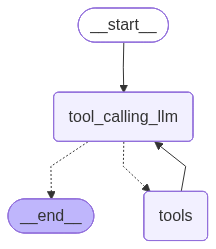

In [23]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

# memory 
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
# This config tells LangGraph which conversation thread to use.
# Calls with the same thread_id share the same saved memory/checkpoints.
# Change the thread_id when you want to start a separate conversation.
config = {
    "configurable":{"thread_id":"1"}
}

In [25]:
response = graph.invoke(
    {"messages": "hello my name is khaled"},
    config=config
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is khaled
================================== Ai Message ==================================

Hello, Khaled! How can I assist you today?


In [26]:
response = graph.invoke(
    {"messages": "what is my name?"},
    config=config
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is khaled
================================== Ai Message ==================================

Hello, Khaled! How can I assist you today?
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Khaled. Let me know if there's anything I can help with!


In [27]:
response['messages'][-1].content

"Your name is Khaled. Let me know if there's anything I can help with!"

## Streaming

Streaming lets us see the graph's progress while it is running instead of waiting for the final result from `invoke()`. This is useful for chatbots because the user can start seeing output sooner, and it is also useful for debugging because we can inspect what each graph step returns.

In this section we build a simple memory-enabled graph with one node named `bot`. The node receives the current `messages`, sends them to the LLM, and returns the LLM response back into the graph state. Because the graph is compiled with a `MemorySaver` checkpointer, calls that use the same `thread_id` can continue the same conversation history.


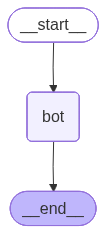

In [28]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def bot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

graph=StateGraph(State)

graph.add_node("bot",bot)

graph.add_edge(START,"bot")
graph.add_edge("bot",END)


graph_builder=graph.compile(checkpointer=memory)


from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [29]:
# The thread_id chooses which saved conversation memory to use.
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke(
    {'messages':"Hi,My name is ،khaled And I like cricket"}
    ,config
    )

{'messages': [HumanMessage(content='Hi,My name is ،khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='4e2886cf-06c8-4114-895d-b1a87a6fa3bd'),
  AIMessage(content="<think>\nOkay, the user is named Khaled and he likes cricket. I need to respond warmly and engage him. Let me start by greeting him back and acknowledging his interest in cricket.\n\nMaybe ask him about his favorite team or what he enjoys most about the game. That way, I can keep the conversation going and show genuine interest. Also, since cricket is popular in many countries, it might be good to mention some popular leagues or teams to see if he connects with any. I should keep the tone friendly and open-ended to encourage him to share more.\n</think>\n\nHi Khaled! Welcome! 🏏 I'm glad to hear you love cricket. It's an amazing sport with so much excitement and strategy. \n\nDo you follow any particular team or league? Whether it's the IPL, T20 World Cup, or Test cricket, there's something for everyon

## Streaming

LangGraph gives us a few ways to stream a graph run:

- `.stream()` is the synchronous streaming method. Use it with a normal `for` loop.
- `.astream()` is the asynchronous version of `.stream()`. Use it with `async for` when your code is async.
- `.astream_events()` streams lower-level events, such as model token chunks, chain starts, chain ends, and graph node events. This is useful when you want detailed tracing or token-by-token behavior.

`stream_mode` controls what each streamed chunk contains:

- `stream_mode="updates"` returns only the changes produced by each node. In this graph, the `bot` node returns a new AI message, so the streamed chunk is shaped like `{"bot": {"messages": [...]}}`.
- `stream_mode="values"` returns the full graph state after each step. Because our state has one key, `messages`, each streamed chunk contains the whole message history available at that point.

The `config` still matters during streaming. If we pass the same `thread_id`, the stream continues the same saved conversation. If we use a new `thread_id`, LangGraph starts a separate memory thread.


In [30]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream(
    {'messages':"Hi,My name is khaled And I like cricket"},
    config,
    stream_mode="updates"
    ):
    print(chunk)

{'bot': {'messages': [AIMessage(content='<think>\nOkay, the user introduced himself as Khaled and mentioned he likes cricket. I should acknowledge his name and show interest in his hobby. Maybe ask him about his favorite team or player. I need to keep the conversation friendly and open-ended. Let me make sure to respond warmly and invite him to share more if he wants. Also, check for any typos in the response. Alright, time to put that together.\n</think>\n\nHello Khaled! Nice to meet you. Cricket is an awesome sport—I’d love to hear more about what you enjoy about it. Do you follow any particular team or player? Or maybe you play yourself? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 19, 'total_tokens': 152, 'completion_time': 0.316028725, 'completion_tokens_details': None, 'prompt_time': 0.000573174, 'prompt_tokens_details': None, 'queue_time': 0.05474281, 'total_time': 0.316601899}, 'model_name': 'qwen/qwen3-32b', 'system_fi

In [31]:
# stream_mode="values" shows the full state after each step.
# Since this uses the same config as above, the graph keeps using thread_id="3" memory.
for chunk in graph_builder.stream(
    {'messages':"Hi,My name is khaled And I like football"},
    config,
    stream_mode="values"
    ):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='5264d6c0-97b7-41b5-a02e-42a486f8653f'), AIMessage(content='<think>\nOkay, the user introduced himself as Khaled and mentioned he likes cricket. I should acknowledge his name and show interest in his hobby. Maybe ask him about his favorite team or player. I need to keep the conversation friendly and open-ended. Let me make sure to respond warmly and invite him to share more if he wants. Also, check for any typos in the response. Alright, time to put that together.\n</think>\n\nHello Khaled! Nice to meet you. Cricket is an awesome sport—I’d love to hear more about what you enjoy about it. Do you follow any particular team or player? Or maybe you play yourself? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 19, 'total_tokens': 152, 'completion_time': 0.316028725, 'completion_tokens_details': None, 'prompt_tim

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='5264d6c0-97b7-41b5-a02e-42a486f8653f'), AIMessage(content='<think>\nOkay, the user introduced himself as Khaled and mentioned he likes cricket. I should acknowledge his name and show interest in his hobby. Maybe ask him about his favorite team or player. I need to keep the conversation friendly and open-ended. Let me make sure to respond warmly and invite him to share more if he wants. Also, check for any typos in the response. Alright, time to put that together.\n</think>\n\nHello Khaled! Nice to meet you. Cricket is an awesome sport—I’d love to hear more about what you enjoy about it. Do you follow any particular team or player? Or maybe you play yourself? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 19, 'total_tokens': 152, 'completion_time': 0.316028725, 'completion_tokens_details': None, 'prompt_tim

In [32]:
# Another streamed call on the same thread.
# With values mode, the printed chunk includes the accumulated messages state.
for chunk in graph_builder.stream(
    {'messages':"I also like handball"},
    config,
    stream_mode="values"
    ):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='5264d6c0-97b7-41b5-a02e-42a486f8653f'), AIMessage(content='<think>\nOkay, the user introduced himself as Khaled and mentioned he likes cricket. I should acknowledge his name and show interest in his hobby. Maybe ask him about his favorite team or player. I need to keep the conversation friendly and open-ended. Let me make sure to respond warmly and invite him to share more if he wants. Also, check for any typos in the response. Alright, time to put that together.\n</think>\n\nHello Khaled! Nice to meet you. Cricket is an awesome sport—I’d love to hear more about what you enjoy about it. Do you follow any particular team or player? Or maybe you play yourself? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 19, 'total_tokens': 152, 'completion_time': 0.316028725, 'completion_tokens_details': None, 'prompt_tim

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='5264d6c0-97b7-41b5-a02e-42a486f8653f'), AIMessage(content='<think>\nOkay, the user introduced himself as Khaled and mentioned he likes cricket. I should acknowledge his name and show interest in his hobby. Maybe ask him about his favorite team or player. I need to keep the conversation friendly and open-ended. Let me make sure to respond warmly and invite him to share more if he wants. Also, check for any typos in the response. Alright, time to put that together.\n</think>\n\nHello Khaled! Nice to meet you. Cricket is an awesome sport—I’d love to hear more about what you enjoy about it. Do you follow any particular team or player? Or maybe you play yourself? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 19, 'total_tokens': 152, 'completion_time': 0.316028725, 'completion_tokens_details': None, 'prompt_tim

In [33]:
# Use a new thread_id so this async streaming example has its own memory.
config = {
    "configurable": {"thread_id": "5"}
    }

# astream_events gives detailed runtime events instead of only graph state.
# For example, on_chat_model_stream events contain token/message chunks from the LLM.
# version="v2" asks LangGraph to use the newer event schema.
async for event in graph_builder.astream_events(
    {"messages":["Hi My name is khaled and I like to play cricket"]},
    config,
    version="v2"
    ):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is khaled and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019de3a8-e11c-7032-9b49-81a10f1e91e7', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is khaled and I like to play cricket', additional_kwargs={}, response_metadata={}, id='393dc9ce-d635-4845-bbda-a1f9311ab9c7')]}}, 'name': 'bot', 'tags': ['graph:step:1'], 'run_id': '019de3a8-e11d-76f2-8523-06a42f81b402', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'bot', 'langgraph_triggers': ('branch:to:bot',), 'langgraph_path': ('__pregel_pull', 'bot'), 'langgraph_checkpoint_ns': 'bot:76ceb050-52d9-0dfc-f7d0-3a3e54fc0168'}, 'parent_ids': ['019de3a8-e11c-7032-9b49-81a10f1e91e7']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content

{'event': 'on_chat_model_stream', 'data': {'chunk': AIMessageChunk(content=' looking', additional_kwargs={}, response_metadata={'model_provider': 'groq'}, id='lc_run--019de3a8-e11e-7110-8077-cfe843923998', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}, 'run_id': '019de3a8-e11e-7110-8077-cfe843923998', 'name': 'ChatGroq', 'tags': ['seq:step:1'], 'metadata': {'thread_id': '5', 'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'bot', 'langgraph_triggers': ('branch:to:bot',), 'langgraph_path': ('__pregel_pull', 'bot'), 'langgraph_checkpoint_ns': 'bot:76ceb050-52d9-0dfc-f7d0-3a3e54fc0168', 'checkpoint_ns': 'bot:76ceb050-52d9-0dfc-f7d0-3a3e54fc0168', 'ls_provider': 'groq', 'ls_model_name': 'qwen/qwen3-32b', 'ls_model_type': 'chat', 'ls_temperature': 0.7}, 'parent_ids': ['019de3a8-e11c-7032-9b49-81a10f1e91e7', '019de3a8-e11d-76f2-8523-06a42f81b402']}
{'event': 'on_chat_model_stream', 'data': {'chunk': AIMessageChunk(content=' for', additional_kwarg

In [34]:
# This streams low-level runtime events from the graph.
# We filter for on_chat_model_stream so we only print the LLM text chunks.

event_config = {
    "configurable": {"thread_id": "6"}
}

async for event in graph_builder.astream_events(
    {"messages": ["Give me one short sentence about cricket"]},
    event_config,
    version="v2"
):
    if event["event"] == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="")

<think>
Okay, the user asked for a short sentence about cricket. Let me think. They might be looking for something general, maybe a definition or a key fact. Cricket is a sport, played with a bat and ball. It's popular in countries like England, India, Australia. I should mention the basic objective, like scoring runs. Also, maybe the different formats like Test, ODI, T20. But they want a short sentence, so I need to keep it concise. Avoid complex terms. Maybe start with "Cricket is a bat-and-ball game..." played between two teams. The goal is to score more runs than the opposing team. That covers the basics. Let me check if that's accurate. Yeah, that works. Make sure it's one sentence and not too long. Alright, that should do it.
</think>

Cricket is a bat-and-ball game where two teams compete to score the most runs by hitting the ball and rotating the strike.

## Human In the Loop

This section shows how to pause a LangGraph workflow and ask a person for help when the agent needs it. The `human_assistance` tool uses `interrupt()` to stop execution, and the graph continues later when a `Command(resume=...)` value is sent back in.

Human-in-the-loop is useful when the model should not guess on its own: for example, when it needs approval, expert review, missing information, or a decision from a real user. Instead of producing a final answer immediately, the graph pauses at a controlled point and returns a request to the outside application. The application can then show that request to a person, collect the answer, and resume the same run.

The important pieces are:

- `interrupt()` pauses execution and sends data out to the caller.
- `MemorySaver` stores the checkpoint so the paused graph can continue later.
- `Command(resume=...)` sends the human response back into the interrupted tool call.


### Initialize the chat model

We create a fresh `llm` for this example so the human-in-the-loop graph is self-contained. This is the same model setup used earlier; the new behavior comes from binding a normal search tool and a custom human-assistance tool to the model.


In [35]:
import os
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x72d4be4b11d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72d4be4b3ed0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Define a tool that can pause the graph

The `human_assistance` function is registered as a normal LangChain tool with `@tool`, so the LLM can choose it like any other tool. The difference is the call to `interrupt({"query": query})`: when that line runs, LangGraph pauses the workflow and returns the query payload to the caller.

The graph must be compiled with a checkpointer because an interrupted run needs to be saved between the pause and the later resume. `MemorySaver` keeps that checkpoint in memory, which is enough for a notebook demo.


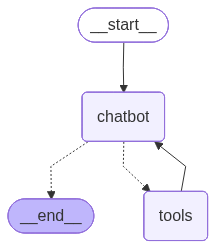

In [ ]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    # Pause the graph and send the request to the outside application.
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# A checkpointer is required so LangGraph can resume after an interrupt.
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

# Visualize the compiled graph.
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Run until the graph asks for a person

This prompt is written to make the model call the `human_assistance` tool. When the graph streams this input, execution reaches the tool node and pauses at `interrupt()`. The printed messages show the assistant's tool call, but there is no final answer yet because the workflow is waiting for human input.


In [37]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (h0gy23tea)
 Call ID: h0gy23tea
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (h0gy23tea)
 Call ID: h0gy23tea
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?


### Resume with the human answer

After a person supplies guidance, wrap that answer in `Command(resume={...})` and stream the same graph again with the same `config`. LangGraph restores the interrupted checkpoint, passes the `data` value back into `human_assistance`, appends the resulting tool message, and lets the chatbot node produce the final response.


In [38]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (h0gy23tea)
 Call ID: h0gy23tea
  Args:
    query: I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

LangGraph (part of the LangChain ecosystem) is an excellent choice for building AI agents. It provides a structured, graph-based approach to agent development with key advantages:

1. **Stateful & Concurrent Agents**: Maintain context across interactions and handle multiple tasks simultaneously
2. **Graph-Based Workflows**: Define complex agent behavior through nodes/edges (e.g